In [1]:
import pathlib 

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pickle

import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [8]:
if not (m.params.data_dir / "morph_hists.pkl").exists():
    script_path = m.params.repo_dir / "src" / "morph_analyses" / "empirical_priors.py"
    !python {script_path}

with open(m.params.data_dir / "morph_hists.pkl", 'rb') as file:
    morph_dict = pickle.load(file)
    
rare_dists = m.empirical_priors.prior_post(morph_dict['rare'])
freq_dists = m.empirical_priors.prior_post(morph_dict['frequent'])

## Plot priors 

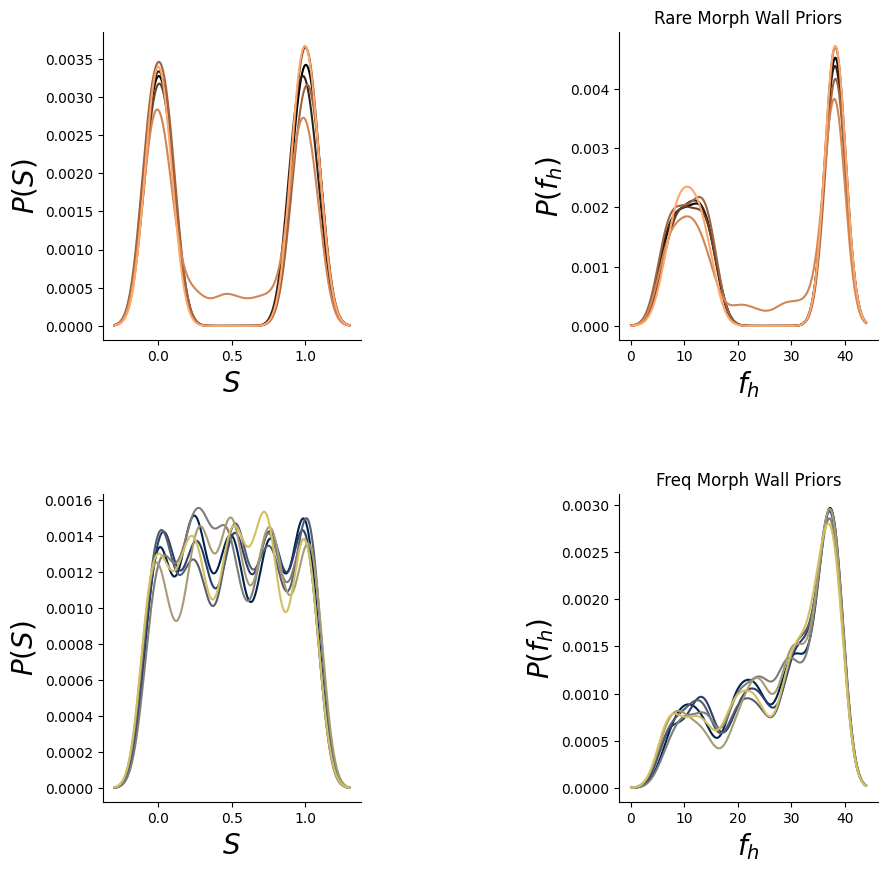

In [9]:
x = np.linspace(-.3,1.3,num=1000)[np.newaxis,:]
f,ax = plt.subplots(2,2,figsize=[10,10])

rare_mice = m.mouse_metadata.rare_mice
for row in range(len(rare_mice)):
    ax[0,0].plot(x.ravel(),rare_dists['each_mouse_morph_prior'][row,:].ravel(),color=plt.cm.copper(float(row)/float(len(rare_mice))))
    ax[0,1].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),rare_dists['each_mouse_wallmorph_prior'][row,:].ravel(),color=plt.cm.copper(float(row)/float(len(rare_mice))))

freq_mice = m.mouse_metadata.frequent_mice
for row in range(len(freq_mice)):
    ax[1,0].plot(x.ravel(),freq_dists['each_mouse_morph_prior'][row,:].ravel(),color=plt.cm.cividis(float(row)/float(len(freq_mice))))
    ax[1,1].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),freq_dists['each_mouse_wallmorph_prior'][row,:].ravel(),color=plt.cm.cividis(float(row)/float(len(freq_mice))))

f.subplots_adjust(hspace=.5)
ax[0,0].set_xlabel("$S$",fontsize=20)
ax[0,0].set_ylabel("$P(S)$",fontsize=20)
ax[0,1].set_xlabel("$f_h$",fontsize=20)
ax[0,1].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,1].set_title('Rare Morph Wall Priors')

ax[1,0].set_xlabel("$S$",fontsize=20)
ax[1,0].set_ylabel("$P(S)$",fontsize=20)
ax[1,1].set_xlabel("$f_h$",fontsize=20)
ax[1,1].set_ylabel("$P(f_h)$",fontsize=20)
ax[1,1].set_title('Freq Morph Wall Priors')
f.subplots_adjust(wspace=1)

ax[0,0].spines['top'].set_visible(False)
ax[0,0].spines['right'].set_visible(False)
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)
ax[1,0].spines['top'].set_visible(False)
ax[1,0].spines['right'].set_visible(False)
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)

## Plot posteriors

Text(0.5, 1.0, '$log(P(f_h|\\hat{f}_h))$')

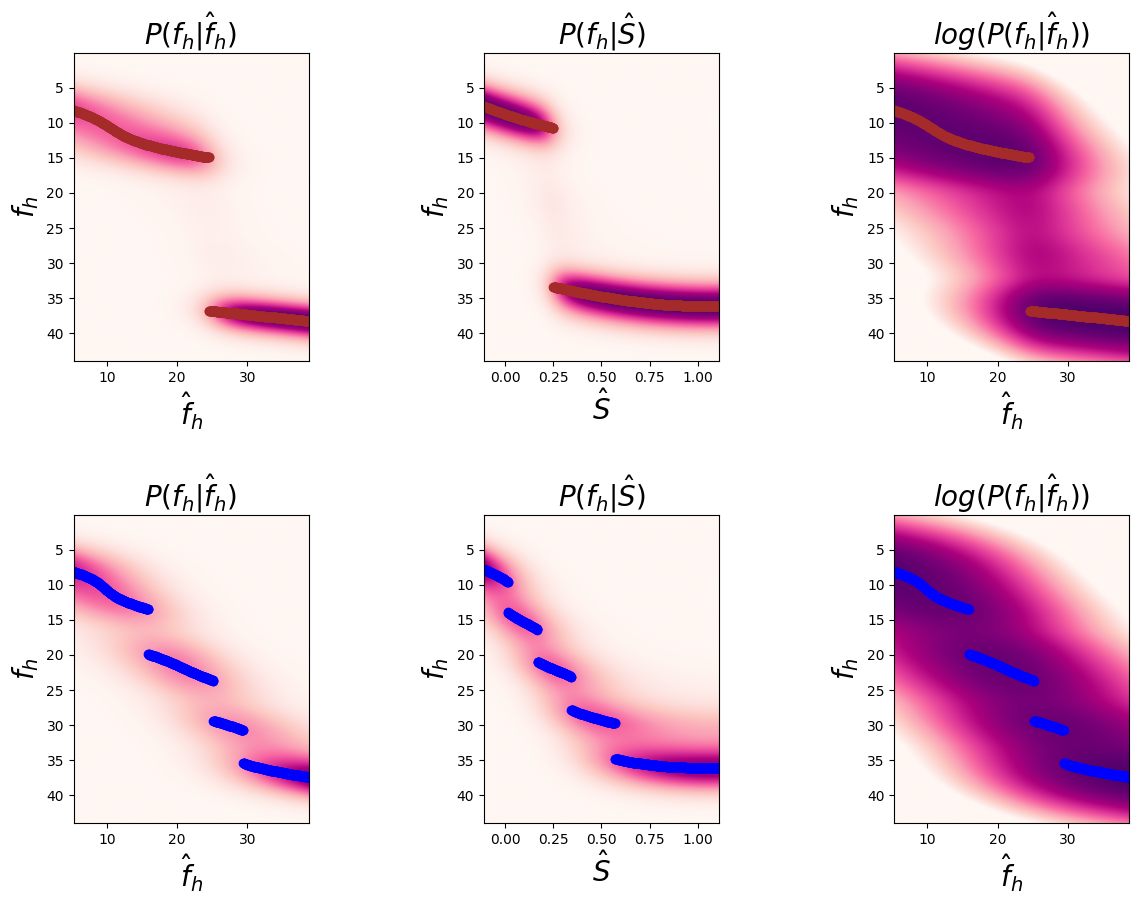

In [10]:
xx = np.linspace(-.3,1.3,num=1000)
log_rare_post,log_freq_post = np.log(rare_dists['wallmorph_posterior']), np.log(freq_dists['wallmorph_posterior'])


f,ax = plt.subplots(2,3,figsize=[15,10])
f.subplots_adjust(hspace=.5)

rare_yhat_wallmorph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(rare_dists['wallmorph_posterior'], axis=1)].ravel())
low,high = m.unity_transforms.inv_wallmorphx(-.3),m.unity_transforms.inv_wallmorphx(1.3)
ax[0,0].imshow(rare_dists['wallmorph_posterior'].T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(rare_dists['wallmorph_posterior'],20))
ax[0,0].scatter(m.unity_transforms.inv_wallmorphx(x),rare_yhat_wallmorph,color='brown')
ax[0,0].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[0,0].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[0,0].set_ylabel("$f_{h}$",fontsize=20)
ax[0,0].set_title("$P(f_h|\hat{f}_h)$",fontsize=20)


rare_yhat_morph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(rare_dists['morph_posterior'], axis=1)].ravel())
ax[0,1].imshow(rare_dists['morph_posterior'].T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(rare_dists['morph_posterior'],20),aspect=(1.6)/(high-low))
ax[0,1].scatter(xx,rare_yhat_morph,color='brown')

ax[0,1].set_xlim([-.11,1.11])
ax[0,1].set_xlabel("$\hat{S}$",fontsize=20)
ax[0,1].set_ylabel("$f_{h}$",fontsize=20)
ax[0,1].set_title("$P(f_h|\hat{S})$",fontsize=20)

ax[0,2].imshow(log_rare_post.T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(log_rare_post,20))
ax[0,2].scatter(m.unity_transforms.inv_wallmorphx(x),rare_yhat_wallmorph,color='brown')
ax[0,2].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[0,2].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[0,2].set_ylabel("$f_{h}$",fontsize=20)
ax[0,2].set_title("$log(P(f_h|\hat{f}_h))$",fontsize=20)


freq_yhat_wallmorph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(freq_dists['wallmorph_posterior'], axis=1)].ravel())
low,high = m.unity_transforms.inv_wallmorphx(-.3),m.unity_transforms.inv_wallmorphx(1.3)
ax[1,0].imshow(freq_dists['wallmorph_posterior'].T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(freq_dists['wallmorph_posterior'],20))
ax[1,0].scatter(m.unity_transforms.inv_wallmorphx(x),freq_yhat_wallmorph,color='blue')
ax[1,0].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[1,0].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[1,0].set_ylabel("$f_{h}$",fontsize=20)
ax[1,0].set_title("$P(f_h|\hat{f}_h)$",fontsize=20)


freq_yhat_morph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(freq_dists['morph_posterior'], axis=1)].ravel())
ax[1,1].imshow(freq_dists['morph_posterior'].T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(freq_dists['morph_posterior'],20),aspect=(1.6)/(high-low))
ax[1,1].scatter(xx,freq_yhat_morph,color='blue')

ax[1,1].set_xlim([-.11,1.11])
ax[1,1].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,1].set_ylabel("$f_{h}$",fontsize=20)
ax[1,1].set_title("$P(f_h|\hat{S})$",fontsize=20)

ax[1,2].imshow(log_freq_post.T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(log_freq_post,20))
ax[1,2].scatter(m.unity_transforms.inv_wallmorphx(x),freq_yhat_wallmorph,color='blue')
ax[1,2].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[1,2].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[1,2].set_ylabel("$f_{h}$",fontsize=20)
ax[1,2].set_title("$log(P(f_h|\hat{f}_h))$",fontsize=20)


## Predicted similarity matrices if neurons represent posterior

Text(0.5, 1.0, 'Rare - Frequent')

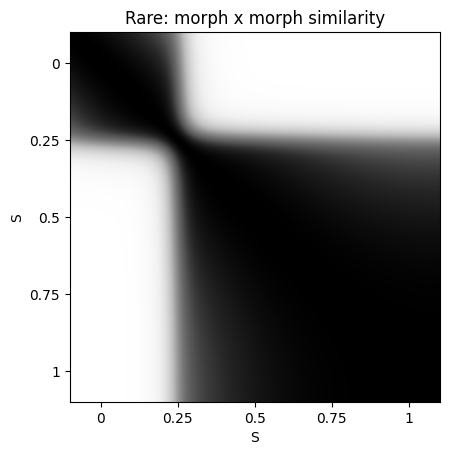

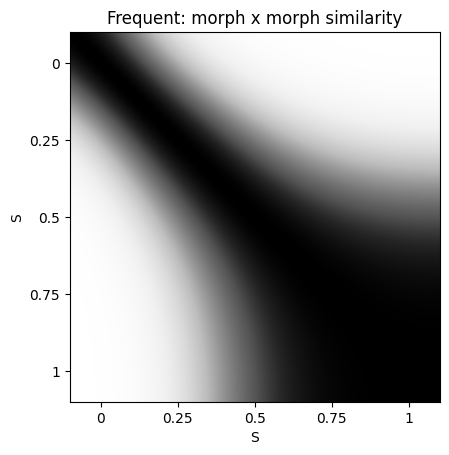

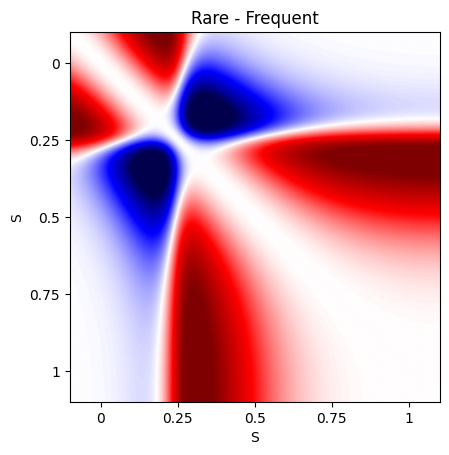

In [11]:
norm_rare_morph_post= rare_dists['morph_posterior']/np.linalg.norm(rare_dists['morph_posterior'],axis=1,ord=2,keepdims=True)
rare_post_sim_mat = np.matmul(norm_rare_morph_post,norm_rare_morph_post.T)

f,ax = plt.subplots()
ax.imshow(rare_post_sim_mat,cmap='Greys',vmin=1E-5, vmax=1, extent=[-.3,1.3,1.3,-.3])

ax.set_xticks([0,.25,.5,.75,1])
ax.set_xticklabels([0,.25,.5,.75,1])
ax.set_yticks([1,.75,.5,.25,.0])
ax.set_yticklabels([1,.75,.5,.25,0])
ax.set_xlim([-.1,1.1])
ax.set_ylim([1.1,-.1])
ax.set_xlabel('S')
ax.set_ylabel('S')
ax.set_title('Rare: morph x morph similarity')

norm_freq_morph_post= freq_dists['morph_posterior']/np.linalg.norm(freq_dists['morph_posterior'],axis=1,ord=2,keepdims=True)
freq_post_sim_mat = np.matmul(norm_freq_morph_post,norm_freq_morph_post.T)

f,ax = plt.subplots()
ax.imshow(freq_post_sim_mat,cmap='Greys',vmin=1E-5, vmax=1, extent=[-.3,1.3,1.3,-.3])

ax.set_xticks([0,.25,.5,.75,1])
ax.set_xticklabels([0,.25,.5,.75,1])
ax.set_yticks([1,.75,.5,.25,.0])
ax.set_yticklabels([1,.75,.5,.25,0])
ax.set_xlim([-.1,1.1])
ax.set_ylim([1.1,-.1])
ax.set_xlabel('S')
ax.set_ylabel('S')
ax.set_title('Frequent: morph x morph similarity')


f,ax = plt.subplots()
ax.imshow(rare_post_sim_mat - freq_post_sim_mat,cmap='seismic',vmin=-.4, vmax=.4, extent=[-.3,1.3,1.3,-.3])

ax.set_xticks([0,.25,.5,.75,1])
ax.set_xticklabels([0,.25,.5,.75,1])
ax.set_yticks([1,.75,.5,.25,.0])
ax.set_yticklabels([1,.75,.5,.25,0])
ax.set_xlim([-.1,1.1])
ax.set_ylim([1.1,-.1])
ax.set_xlabel('S')
ax.set_ylabel('S')
ax.set_title('Rare - Frequent')


## Example posteriors with entropy of posterior calculation

Text(0, 0.5, '$f_h$')

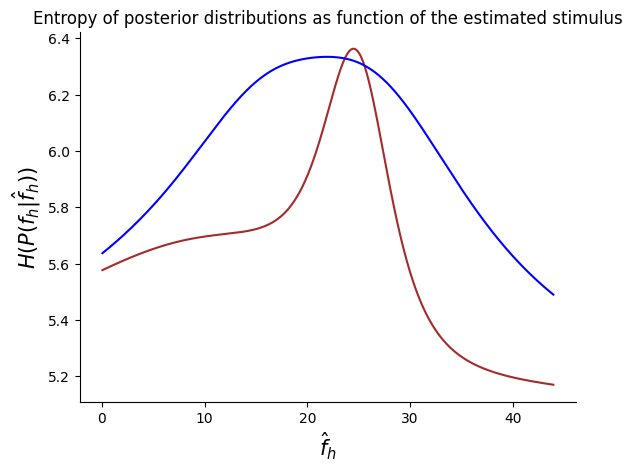

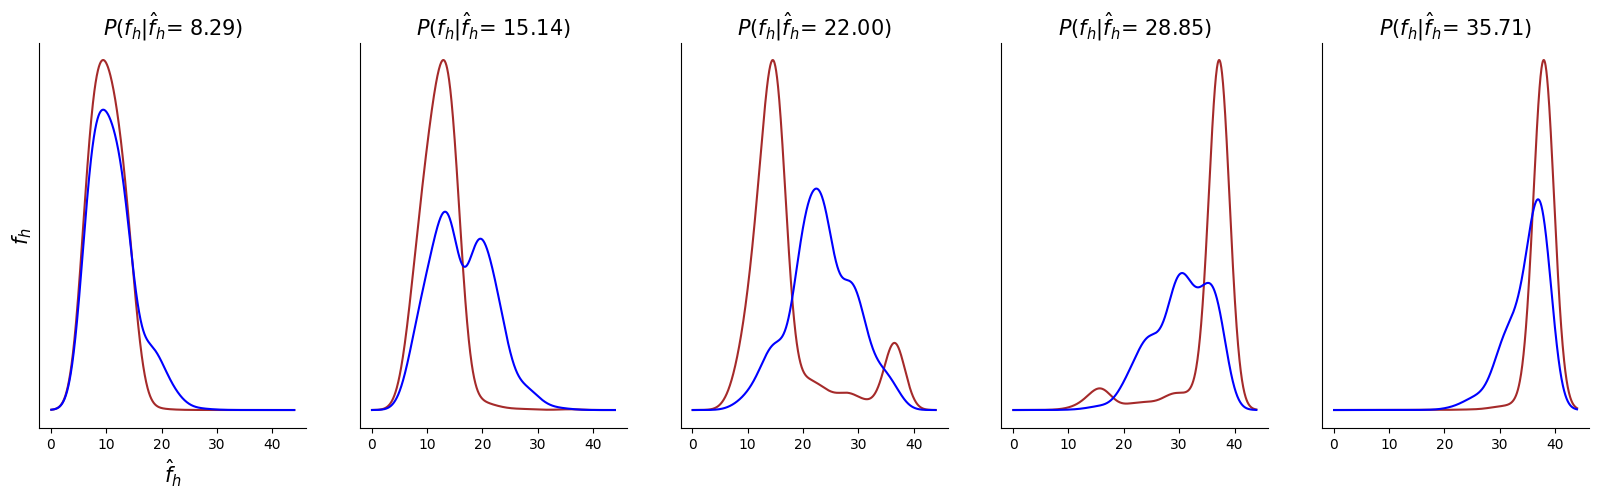

In [16]:
f,ax = plt.subplots()
ax.plot(
    m.unity_transforms.inv_wallmorphx(x.ravel()),
    sp.stats.entropy(rare_dists['wallmorph_posterior'].T),color='brown'
    )
ax.plot(
    m.unity_transforms.inv_wallmorphx(x.ravel()),
    sp.stats.entropy(freq_dists['wallmorph_posterior'].T),color='blue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("$H(P(f_h|\hat{f}_h))$",fontsize=15)
ax.set_xlabel("$\hat{f}_h$",fontsize=15)
ax.set_title("Entropy of posterior distributions as function of the estimated stimulus")


f,ax = plt.subplots(1,5,figsize=[20,5])
for i,_m in enumerate([0,.25,.5,.75,1]):
    ind = np.argmin(np.abs(x.ravel()-_m))
    ax[i].plot(
        m.unity_transforms.inv_wallmorphx(x.ravel()),
        rare_dists['wallmorph_posterior'][ind,:],color='brown'
        )
    ax[i].plot(
        m.unity_transforms.inv_wallmorphx(x.ravel()),
        freq_dists['wallmorph_posterior'][ind,:],color='blue')
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_yticks([])
    ax[i].set_title("$P(f_h|\hat{f}_h$= %.2f$)$" % m.unity_transforms.inv_wallmorphx(_m),fontsize=15)
ax[0].set_xlabel("$\hat{f}_h$",fontsize=15)
ax[0].set_ylabel("$f_h$",fontsize=15)